<a href="https://colab.research.google.com/github/barakatokikiola/Colab_AI_Exercises/blob/main/Tomato_Leaf_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://storage.googleapis.com/kaggle-datasets-images/8201386/12958946/a163d49a7e1451cc12a14dc843f4e65b/dataset-cover.jpg?t=2025-09-04-10-32-49">


In [3]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

## 2. Download Dataset

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("naveedgull/tomato-leaf-disease")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tomato-leaf-disease' dataset.
Path to dataset files: /kaggle/input/tomato-leaf-disease


In [5]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [6]:
os.listdir("/kaggle/input/tomato-leaf-disease/Tomato Leaf Disease/train")

['Tomato___Late_blight',
 'Tomato___healthy',
 'Tomato___Early_blight',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Bacterial_spot',
 'Tomato___Target_Spot',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___Leaf_Mold',
 'Tomato___Spider_mites Two-spotted_spider_mite']

In [7]:
# Dataset config
DATASET_PATH = "/kaggle/input/tomato-leaf-disease/Tomato Leaf Disease"
TRAIN_PATH = os.path.join(DATASET_PATH, "train")
SPLIT_BASE = "/tmp/tomato_split"
SPLIT_TRAIN = os.path.join(SPLIT_BASE, "train")
SPLIT_VAL = os.path.join(SPLIT_BASE, "val")
SPLIT_TEST = os.path.join(SPLIT_BASE, "test")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_SEED = 42

# Map from raw folder name to clean label
CLASS_MAP = {
    "Tomato___healthy": "Healthy",
    "Tomato___Septoria_leaf_spot": "Septoria",
    "Tomato___Target_Spot": "Target Spot",
    "Tomato___Bacterial_spot": "Bacterial Spot"
}
RAW_CLASSES = list(CLASS_MAP.keys())
CLASS_NAMES = list(CLASS_MAP.values())
NUM_CLASSES = len(CLASS_NAMES)

## 4. Split Data into Training and Test Sets

In [8]:
# Build train / val / test splits from the original train folder
random.seed(RANDOM_SEED)

if os.path.exists(SPLIT_BASE):
    shutil.rmtree(SPLIT_BASE)

for raw_cls, clean_name in CLASS_MAP.items():
    src_folder = os.path.join(TRAIN_PATH, raw_cls)
    all_images = [f for f in os.listdir(src_folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    random.shuffle(all_images)

    n = len(all_images)
    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)

    train_imgs = all_images[:n_train]
    val_imgs = all_images[n_train:n_train + n_val]
    test_imgs = all_images[n_train + n_val:]

    for split, imgs in [("train", train_imgs), ("val", val_imgs), ("test", test_imgs)]:
        dest = os.path.join(SPLIT_BASE, split, clean_name)
        os.makedirs(dest, exist_ok=True)
        for img in imgs:
            shutil.copy(os.path.join(src_folder, img), os.path.join(dest, img))

print("Split complete.")
for split in ["train", "val", "test"]:
    for cls in CLASS_NAMES:
        count = len(os.listdir(os.path.join(SPLIT_BASE, split, cls)))
        print(f"  {split}/{cls}: {count} images")

Split complete.
  train/Healthy: 890 images
  train/Septoria: 991 images
  train/Target Spot: 786 images
  train/Bacterial Spot: 1190 images
  val/Healthy: 190 images
  val/Septoria: 212 images
  val/Target Spot: 168 images
  val/Bacterial Spot: 255 images
  test/Healthy: 192 images
  test/Septoria: 213 images
  test/Target Spot: 169 images
  test/Bacterial Spot: 256 images


## 5. Sample Data Visualisation

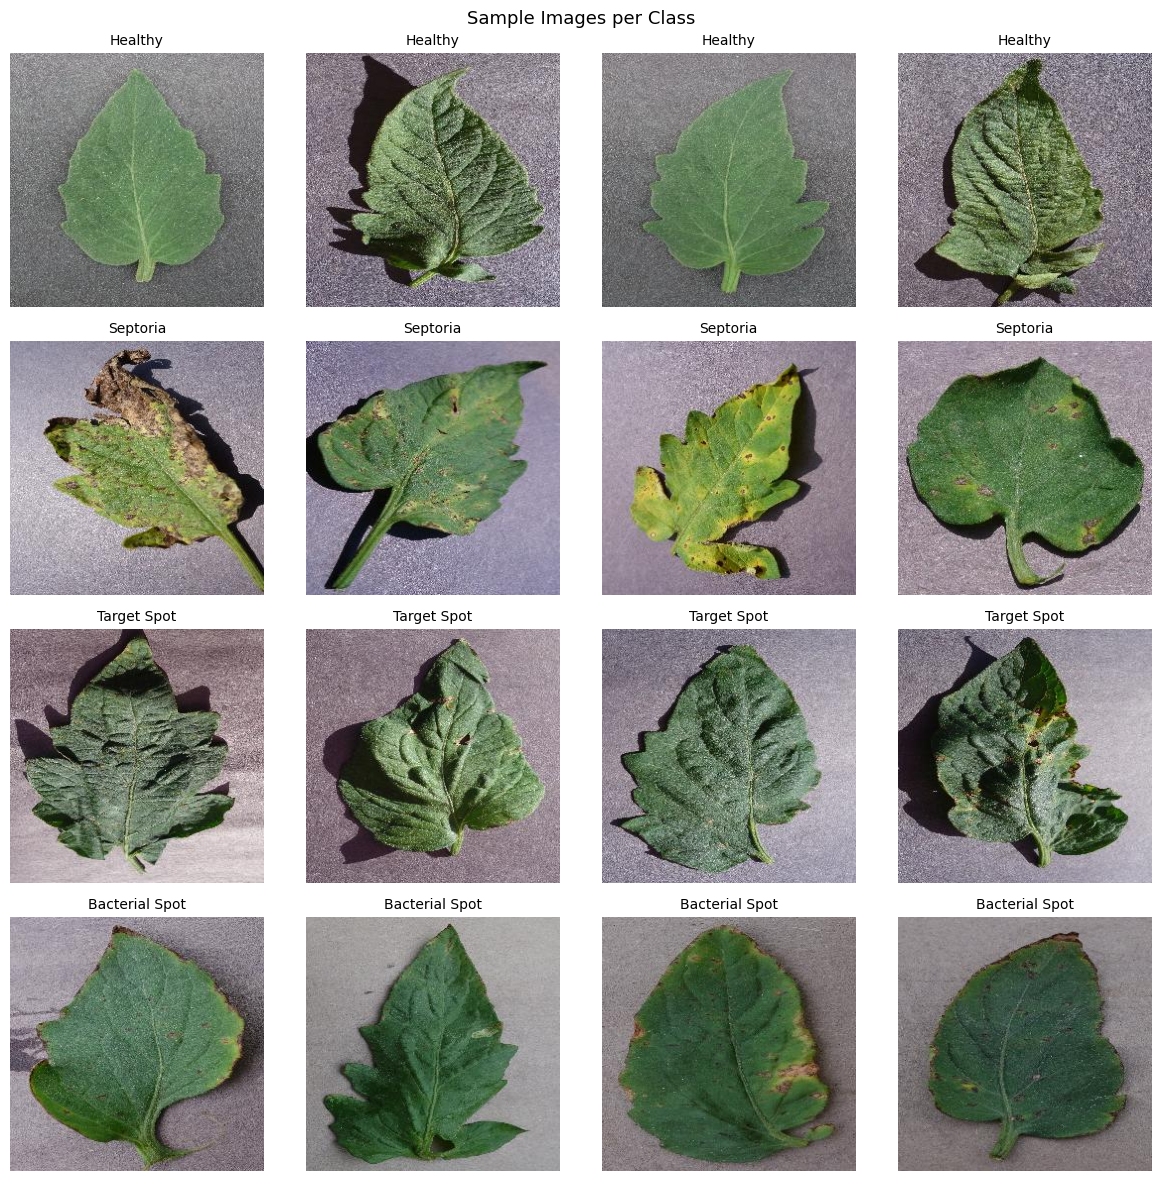

In [9]:
# Each class occupies one row, 4 images per row, label on every image

SAMPLES_PER_CLASS = 4
fig, axes = plt.subplots(NUM_CLASSES, SAMPLES_PER_CLASS, figsize=(SAMPLES_PER_CLASS * 3, NUM_CLASSES * 3))

for row, cls_name in enumerate(CLASS_NAMES):
    cls_folder = os.path.join(SPLIT_TRAIN, cls_name)
    images = [f for f in os.listdir(cls_folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))][:SAMPLES_PER_CLASS]

    for col, img_name in enumerate(images):
        img_path = os.path.join(cls_folder, img_name)
        img = plt.imread(img_path)
        axes[row][col].imshow(img)
        axes[row][col].axis("off")
        # Label on every image
        axes[row][col].set_title(cls_name, fontsize=10)

plt.suptitle("Sample Images per Class", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Sample Data Augmentation

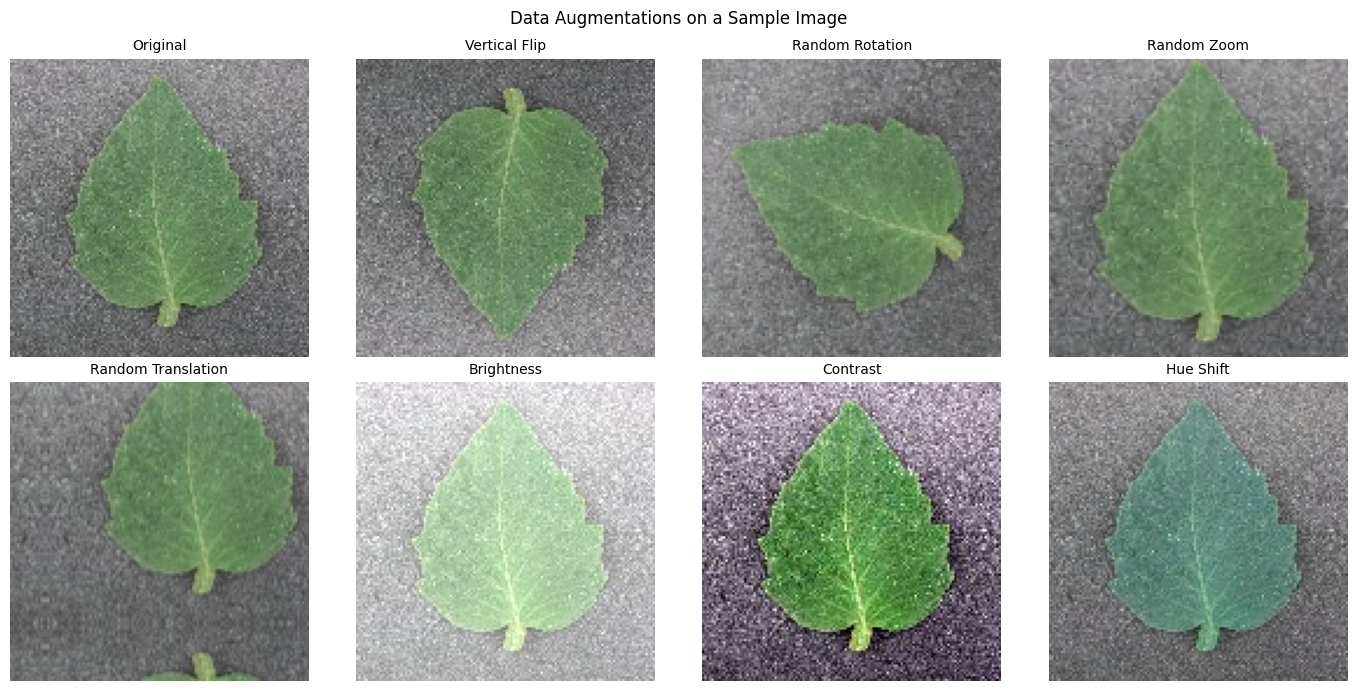

In [10]:
sample_img_folder = os.path.join(SPLIT_TRAIN, CLASS_NAMES[0])
sample_img_file = os.listdir(sample_img_folder)[0]
sample_img_path = os.path.join(sample_img_folder, sample_img_file)

img = tf.keras.utils.load_img(sample_img_path, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img) / 255.0
img_expanded = np.expand_dims(img_array, axis=0)

augmentations = {
    "Original": img_array,
    "Vertical Flip": tf.image.flip_up_down(img_array).numpy(),
    "Random Rotation": tf.keras.layers.RandomRotation(0.3)(img_expanded, training=True)[0].numpy().clip(0, 1),
    "Random Zoom": tf.keras.layers.RandomZoom(0.3)(img_expanded, training=True)[0].numpy().clip(0, 1),
    "Random Translation": tf.keras.layers.RandomTranslation(0.2, 0.2)(img_expanded, training=True)[0].numpy().clip(0, 1),
    "Brightness": tf.image.adjust_brightness(img_array, 0.3).numpy().clip(0, 1),
    "Contrast": tf.image.adjust_contrast(img_array, 2).numpy().clip(0, 1),
    "Hue Shift": tf.image.adjust_hue(img_array, 0.15).numpy().clip(0, 1),
}

aug_titles = list(augmentations.keys())
aug_images = list(augmentations.values())

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, (title, aug_img) in enumerate(augmentations.items()):
    axes[i].imshow(aug_img)
    axes[i].set_title(title, fontsize=10)
    axes[i].axis("off")

plt.suptitle("Data Augmentations on a Sample Image", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Data Generators

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_gen = train_datagen.flow_from_directory(
    SPLIT_TRAIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=RANDOM_SEED
)

Found 3857 images belonging to 4 classes.


In [12]:
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

val_gen = val_test_datagen.flow_from_directory(
    SPLIT_VAL,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 825 images belonging to 4 classes.


In [13]:
test_gen = val_test_datagen.flow_from_directory(
    SPLIT_TEST,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 830 images belonging to 4 classes.


In [14]:
# Class order as assigned by the generator
gen_class_names = [k for k, v in sorted(train_gen.class_indices.items(), key=lambda x: x[1])]
print("Generator class order:", gen_class_names)

Generator class order: ['Bacterial Spot', 'Healthy', 'Septoria', 'Target Spot']


## 8. Convolutional Neural Network (CNN) Model

In [15]:
def build_cnn(num_classes, img_size):
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(*img_size, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

cnn_model = build_cnn(NUM_CLASSES, IMG_SIZE)

In [16]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,156 (1.74 MB)

 Trainable params: 456,196 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [17]:
cnn_callbacks = [
    keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
]

cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=cnn_callbacks
)

Epoch 1/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 38s 235ms/step - accuracy: 0.8841 - loss: 0.3198 - val_accuracy: 0.2303 - val_loss: 4.5150 - learning_rate: 0.0010
Epoch 2/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 21s 176ms/step - accuracy: 0.9318 - loss: 0.2008 - val_accuracy: 0.3636 - val_loss: 6.8831 - learning_rate: 0.0010
Epoch 3/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 21s 172ms/step - accuracy: 0.9396 - loss: 0.1799 - val_accuracy: 0.4521 - val_loss: 4.2855 - learning_rate: 0.0010
Epoch 4/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 22s 180ms/step - accuracy: 0.9476 - loss: 0.1438 - val_accuracy: 0.8206 - val_loss: 0.8211 - learning_rate: 0.0010
Epoch 5/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 21s 173ms/step - accuracy: 0.9596 - loss: 0.1155 - val_accuracy: 0.8655 - val_loss: 0.3717 - learning_rate: 0.0010
Epoch 6/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 21s 177ms/step - accuracy: 0.9539 - loss: 0.1319 - val_accuracy: 0.7915 - val_loss: 0.7890 - learning_rate: 0.0010
Epoch 7/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.95

In [18]:
def evaluate_model(model, test_gen, class_names, model_name):
    test_gen.reset()
    y_pred_probs = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_gen.classes

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{model_name} Test Set Metrics")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{model_name} Confusion Matrix (Test Set)")
    plt.xticks(fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

    # Return true and predicted labels for use outside the function
    return y_true, y_pred

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step

Custom CNN Test Set Metrics
Accuracy:  0.8928
Precision: 0.9131
Recall:    0.8928
F1 Score:  0.8909


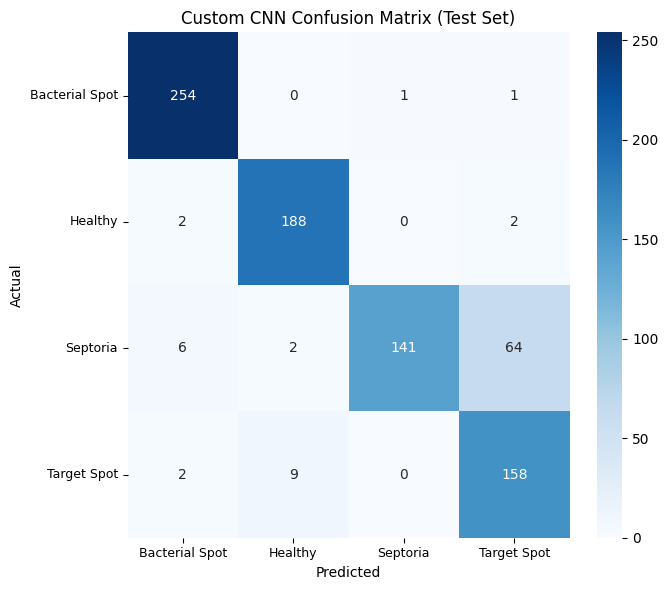

In [19]:
cnn_true, cnn_pred = evaluate_model(cnn_model, test_gen, gen_class_names, "Custom CNN")